# Environmental Impacts on Mental Health in Lincolnshire
This notebook demonstrates a workflow combining dataset loading and processing, synthetic data simulation, machine learning, and model visualisation for a UK environmental mental health use case.

## Problem Framing
Research objective: quantify how environmental pollution exposure (NO2, PM2.5, PM10) and deprivation in urban and rural areas relate to mental health burden (PHQ-9, the Patient Health Questionnaire-9, a standard screening tool for depressive symptom severity).

## Methodology
1. Load DEFRA AURN pollutant data.
2. Simulate 1,000 individuals with demographic, deprivation, and environmental factors.
3. Construct a PHQ-9 target where higher NO2, PM2.5, PM10, and higher deprivation increase expected score.
4. Train a Random Forest Regressor to predict PHQ-9.
5. Use SHAP for visualisation.

## Literature
Studies in the literature report links between high levels of NO2, PM2.5, PM10 and mental health disorders:
- [Roberts, S. et al. "Exploration of NO2 and PM2.5 air pollution and mental health problems using high-resolution data in London-based children from a UK longitudinal cohort study." Psychiatry Research, 272, 8–17.](https://www.sciencedirect.com/science/article/pii/S016517811830800X)
- [Newbury, J. B. et al. "Association between air pollution exposure and mental health service use among individuals with first presentations of psychotic and mood disorders: retrospective cohort study." The British Journal of Psychiatry, 219(6), 678–685.](https://www.cambridge.org/core/journals/the-british-journal-of-psychiatry/article/association-between-air-pollution-exposure-and-mental-health-service-use-among-individuals-with-first-presentations-of-psychotic-and-mood-disorders-retrospective-cohort-study/010F283B9107A5F04C51F90B5D5F96D6)
- [Gao, Xu, et al. "Long-term air pollution, genetic susceptibility, and the risk of depression and anxiety: a prospective study in the UK Biobank cohort." Environmental Health Perspectives 131.1 (2023): 017002.](https://pmc.ncbi.nlm.nih.gov/articles/PMC9812022/)

### Pollutants
- Nitrogen dioxide (NO2)
- PM2.5 (fine particulate matter with a diameter of less than 2.5 micrometres, 0.0025 mm)
- PM10 (fine particulate matter with a diameter of less than 10 micrometres, 0.01 mm)

## DEFRA AURN NO2, PM2.5, PM10 Dataset

DEFRA's Automatic Urban and Rural Network [(AURN dataset)](https://uk-air.defra.gov.uk/networks/network-info?view=aurn).

### Monitoring Sites
- Lincoln Canwick Road
- Immingham Woodlands Avenue
- Scunthorpe Town Rowland Road
- Toft Newton Reservoir (near Market Rasen)
- Tallington River Welland (near Stamford)

| Site Name (UK-AIR ID)           | DEFRA Environment Type | Category        | Pollutants (NO2, PM2.5, PM10) |  Rationale |
|---------------------------------|------------------------|-----------------|-------------------------------|------------|
| Lincoln Canwick Road (UKA00561) | Urban Traffic          | Small Urban-Deprived  | NO2                     | High-density urban roadside, traffic-heavy setting. |
| Scunthorpe Town (UKA00381)      | Urban Industrial       | Small Urban-Deprived  | NO2, PM2.5, PM10        | Industrial urban setting near heavy industry (steelworks). |
| Immingham Woodlands Avenue (UKA00647) | Urban Background | Coastal Industrial    | NO2, PM2.5, PM10        | Industrial urban setting near docks and oil refinery. |
| Toft Newton (UKA01026)          | Rural Background       | Rural                 | NO2, PM2.5, PM10        | Rural baseline cleaner-air environment. |
| Tallington (UKA01038)           | Rural Background       | Rural                 | PM2.5, PM10             | Helps assess transport-related influence in a rural setting (near a trunk road). |

In [1]:
import pandas as pd
import plotly.express as px

# Approximate coordinates for the AURN monitoring sites used in this notebook.
site_map_df = pd.DataFrame([
    {'Site_Name': 'Lincoln Canwick Road', 'Latitude': 53.2194, 'Longitude': -0.5409, 'Type': 'Urban'},
    {'Site_Name': 'Immingham Woodlands Ave', 'Latitude': 53.6286, 'Longitude': -0.2103, 'Type': 'Urban'},
    {'Site_Name': 'Scunthorpe', 'Latitude': 53.5867, 'Longitude': -0.6500, 'Type': 'Urban'},
    {'Site_Name': 'Toft Newton', 'Latitude': 53.4202, 'Longitude': -0.4147, 'Type': 'Rural'},
    {'Site_Name': 'Tallington', 'Latitude': 52.6786, 'Longitude': -0.3768, 'Type': 'Rural'}
])

# Updated to scatter_map (Maplibre path) to avoid deprecation warnings.
fig = px.scatter_map(
    site_map_df,
    lat='Latitude',
    lon='Longitude',
    color='Type',
    text='Site_Name',
    hover_name='Site_Name',
    hover_data={'Latitude': ':.4f', 'Longitude': ':.4f', 'Type': True},
    zoom=7,
    center={'lat': 53.15, 'lon': -0.45},
    color_discrete_map={'Urban': '#1f77b4', 'Rural': '#2ca02c'},
    map_style='carto-positron',
    title='Monitoring Sites Used in the Analysis'
)

fig.update_traces(
    marker={'size': 14, 'opacity': 0.92},
    mode='markers+text',
    textposition='top right',
    textfont={'size': 12, 'color': '#1a1a1a'}
)
fig.update_layout(
    height=400,
    margin={'l': 0, 'r': 0, 't': 64, 'b': 0},
    legend_title_text='Site Type'
)

fig.show()


## 1. Load the AURN data from the csv files.

In [3]:
try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
else:
    print('Google Colab not detected; skipping Drive mount.')

import pandas as pd
import numpy as np
from pathlib import Path

candidate_dirs = [
    Path('code/mental_health_ml/datasets/arun'),
    Path('datasets/arun'),
    Path('/home/cheddar/code/mental_health_ml/datasets/arun'),
    Path('/content/drive/MyDrive/Colab Notebooks/mental_health_ml/datasets/arun')
]
base_dir = next((p for p in candidate_dirs if p.exists()), candidate_dirs[-1])

# Site labels
site_label_map = {
    'immingham': 'Immingham Woodlands',
    'lincoln': 'Lincoln Canwick Road',
    'scunthorpe': 'Scunthorpe Town',
    'tallington': 'Tallington',
    'toft_newton': 'Toft Newton'
}

def infer_pollutant_from_filename(file_name: str) -> str:
    name = file_name.upper()
    if 'NO2' in name:
        return 'NO2'
    if 'PM10' in name:
        return 'PM10'
    if 'PM25' in name or 'PM2.5' in name:
        return 'PM2.5'
    return 'UNKNOWN'

def parse_24h_timestamp(date_series: pd.Series, hour_series: pd.Series) -> pd.Series:
    # DEFRA format uses hour-ending notation and may include 24:00.
    d = pd.to_datetime(date_series, format='%d-%m-%Y', errors='coerce')
    h = hour_series.astype(str).str.strip()
    is_24 = h.eq('24:00')
    h = h.where(~is_24, '00:00')
    dt = pd.to_datetime(d.dt.strftime('%Y-%m-%d') + ' ' + h, format='%Y-%m-%d %H:%M', errors='coerce')
    dt = dt.where(~is_24, dt + pd.Timedelta(days=1))
    return dt

records = []
files_found = sorted(base_dir.rglob('*.csv'))

for f in files_found:
    pollutant = infer_pollutant_from_filename(f.name)
    site_folder = f.parent.name.lower()
    site_name = site_label_map.get(site_folder, f.parent.name)

    # Data starts after 4 metadata lines in these UK-AIR exports.
    raw = pd.read_csv(f, skiprows=4, dtype=str)
    raw.columns = [str(c).strip() for c in raw.columns]

    # First column is date, subsequent columns are hourly values.
    date_col = raw.columns[0]
    raw = raw.rename(columns={date_col: 'Date'})

    # Keep only hour columns from 01:00 to 24:00.
    hour_cols = [c for c in raw.columns if isinstance(c, str) and ':' in c and len(c.strip()) == 5]
    if not hour_cols:
        continue

    long_df = raw[['Date'] + hour_cols].melt(
        id_vars='Date',
        var_name='Hour',
        value_name='Value'
    )

    # Clean blanks and convert to numeric.
    long_df['Value'] = long_df['Value'].astype(str).str.strip()
    long_df['Value'] = long_df['Value'].replace({'': np.nan, 'nan': np.nan})
    long_df['Value'] = pd.to_numeric(long_df['Value'], errors='coerce')

    long_df['Timestamp'] = parse_24h_timestamp(long_df['Date'], long_df['Hour'])
    long_df = long_df.dropna(subset=['Timestamp', 'Value'])

    long_df['Site_Name'] = site_name
    long_df['Pollutant'] = pollutant
    long_df['Source_File'] = f.name

    records.append(long_df[['Timestamp', 'Site_Name', 'Pollutant', 'Value', 'Source_File']])

if records:
    df_aurn = pd.concat(records, ignore_index=True).sort_values('Timestamp')
    df_aurn = df_aurn.reset_index(drop=True)

    availability = (
        df_aurn
        .groupby(['Site_Name', 'Pollutant'])['Value']
        .count()
        .rename('N_Observations')
        .reset_index()
        .sort_values(['Site_Name', 'Pollutant'])
    )

    print(f'Loaded {len(files_found)} CSV files from {base_dir.resolve()}')
    display(availability)
    display(df_aurn.head())
else:
    print(f'No CSV data loaded from {base_dir.resolve()}. Check folder path and file contents.')

Google Colab not detected; skipping Drive mount.
Loaded 12 CSV files from /home/cheddar/code/mental_health_ml/datasets/arun


,Site_Name,Pollutant,N_Observations
0,Immingham Woodlands,NO2,8664
1,Immingham Woodlands,PM10,8754
2,Immingham Woodlands,PM2.5,8754
3,Lincoln Canwick Road,NO2,8206
4,Scunthorpe Town,NO2,8665
5,Scunthorpe Town,PM10,8523
6,Scunthorpe Town,PM2.5,6632
7,Tallington,PM10,8714
8,Tallington,PM2.5,8714
9,Toft Newton,NO2,5892


,Timestamp,Site_Name,Pollutant,Value,Source_File
0,2025-01-01 01:00:00,Immingham Woodlands,NO2,1.43264,IMGM_NO2_2025.csv
1,2025-01-01 01:00:00,Immingham Woodlands,PM2.5,2.99500,IMGM_PM25_2025.csv
2,2025-01-01 01:00:00,Scunthorpe Town,PM10,8.69600,SCN2_PM10_2025.csv
3,2025-01-01 01:00:00,Tallington,PM10,5.95000,TALL_PM10_2025.csv
4,2025-01-01 01:00:00,Tallington,PM2.5,3.16000,TALL_PM25_2025.csv


In [ ]:
# Pivot long-format AURN data to wide hourly features per site.
# Input expected: df_aurn with columns [Timestamp, Site_Name, Pollutant, Value].
required_cols = {'Timestamp', 'Site_Name', 'Pollutant', 'Value'}
missing_cols = required_cols - set(df_aurn.columns)
if missing_cols:
    raise ValueError(f'df_aurn is missing required columns: {missing_cols}')

# If duplicate rows exist for the same site-time-pollutant, average them.
df_aurn_hourly_wide = (
    df_aurn
    .groupby(['Timestamp', 'Site_Name', 'Pollutant'], as_index=False)['Value']
    .mean()
    .pivot(index=['Timestamp', 'Site_Name'], columns='Pollutant', values='Value')
    .reset_index()
)

# Ensure expected pollutant columns exist even if absent at some sites.
for col in ['NO2', 'PM10', 'PM2.5']:
    if col not in df_aurn_hourly_wide.columns:
        df_aurn_hourly_wide[col] = np.nan

# Optional daily aggregation by site to ease person-level merging.
df_aurn_daily_site = (
    df_aurn_hourly_wide
    .assign(Date=lambda x: x['Timestamp'].dt.date)
    .groupby(['Date', 'Site_Name'], as_index=False)[['NO2', 'PM10', 'PM2.5']]
    .mean()
)

print(f'Hourly wide shape: {df_aurn_hourly_wide.shape}')
print(f'Daily site shape: {df_aurn_daily_site.shape}')
display(df_aurn_hourly_wide.head())
display(df_aurn_daily_site.head())

Hourly wide shape: (43154, 5)
Daily site shape: (1815, 5)


Pollutant,Timestamp,Site_Name,NO2,PM10,PM2.5
0,2025-01-01 01:00:00,Immingham Woodlands,1.43264,4.700,2.995
1,2025-01-01 01:00:00,Lincoln Canwick Road,3.33925,NaN,NaN
2,2025-01-01 01:00:00,Scunthorpe Town,1.70066,8.696,NaN
3,2025-01-01 01:00:00,Tallington,NaN,5.950,3.160
4,2025-01-01 01:00:00,Toft Newton,1.03291,4.725,2.736


Pollutant,Date,Site_Name,NO2,PM10,PM2.5
0,2025-01-01,Immingham Woodlands,4.302595,3.929348,2.068261
1,2025-01-01,Lincoln Canwick Road,8.325191,NaN,NaN
2,2025-01-01,Scunthorpe Town,5.388073,8.401783,NaN
3,2025-01-01,Tallington,NaN,3.267391,1.781174
4,2025-01-01,Toft Newton,1.511753,3.284783,1.731913


## 2. Data Simulation
We simulate a synthetic dataset of 1,000 individuals suitable for modelling, while keeping environmental exposures anchored to real DEFRA AURN monitoring data.

Each simulated individual is assigned:
- `Age`
- `IMD Decile` (1-10)
- `Urban Rural Status` (ONS-style categories)
- `Site Name`
- `Month` and `Season` derived from real monitoring timestamps
- `NO2 Exposure`, `PM2.5 Exposure`, and `PM10 Exposure` (sampled from real site-level hourly AURN observations)
- `Comorbidity Risk`, a simulated health-vulnerability score (0 to 1) derived from age, deprivation, and random variation
- `Site Random Effect`, a small site-level contextual offset capturing unmeasured local influences (for example local stressors or access to services)

IMD data are informed by the [2025 Index of Multiple Deprivation (IMD)](https://www.gov.uk/government/statistics/english-indices-of-deprivation-2025), where individuals are assigned IMD values within ranges reflecting the areas around each site.

This means the outcome data are simulated, but the exposure patterns, site differences, and seasonality are grounded in the observed monitoring data.

In [ ]:
import pandas as pd
import numpy as np

rng = np.random.default_rng(42)
n = 1000

# 1) Define sites and environment type
site_names = [
    'Lincoln Canwick Road',
    'Scunthorpe Town',
    'Immingham Woodlands',
    'Toft Newton',
    'Tallington'
]
site_probs = np.array([0.24, 0.22, 0.18, 0.18, 0.18])
site_to_environment = {
    'Lincoln Canwick Road': 'Urban',
    'Scunthorpe Town': 'Urban',
    'Immingham Woodlands': 'Urban',
    'Toft Newton': 'Rural',
    'Tallington': 'Rural'
}
site_to_ons = {
    'Lincoln Canwick Road': 'Urban city and town',
    'Scunthorpe Town': 'Urban city and town',
    'Immingham Woodlands': 'Urban city and town',
    'Toft Newton': 'Rural hamlets and isolated dwellings',
    'Tallington': 'Rural town and fringe'
}

# 2) Prepare real hourly exposure pool from AURN data (wide format)
if 'df_aurn_hourly_wide' not in globals():
    df_aurn_hourly_wide = (
        df_aurn
        .groupby(['Timestamp', 'Site_Name', 'Pollutant'], as_index=False)['Value']
        .mean()
        .pivot(index=['Timestamp', 'Site_Name'], columns='Pollutant', values='Value')
        .reset_index()
    )

real_exposure_pool = df_aurn_hourly_wide.copy()
for col in ['NO2', 'PM10', 'PM2.5']:
    if col not in real_exposure_pool.columns:
        real_exposure_pool[col] = np.nan

real_exposure_pool = real_exposure_pool[['Timestamp', 'Site_Name', 'NO2', 'PM2.5', 'PM10']]
real_exposure_pool = real_exposure_pool[real_exposure_pool['Site_Name'].isin(site_names)].copy()
real_exposure_pool['Environment_Type'] = real_exposure_pool['Site_Name'].map(site_to_environment)
real_exposure_pool['Month'] = real_exposure_pool['Timestamp'].dt.month

season_map = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn'
}
real_exposure_pool['Season'] = real_exposure_pool['Month'].map(season_map)

# 3) Data-driven imputation for missing site-hour pollutants using real data patterns
for pol in ['NO2', 'PM2.5', 'PM10']:
    by_env_month = real_exposure_pool.groupby(['Environment_Type', 'Month'])[pol].transform('mean')
    by_env = real_exposure_pool.groupby('Environment_Type')[pol].transform('mean')
    global_mean = real_exposure_pool[pol].mean()

    real_exposure_pool[pol] = real_exposure_pool[pol].fillna(by_env_month)
    real_exposure_pool[pol] = real_exposure_pool[pol].fillna(by_env)
    real_exposure_pool[pol] = real_exposure_pool[pol].fillna(global_mean)

# Site constants derived from real (imputed) data
site_pollutant_annual_means = (
    real_exposure_pool
    .groupby(['Site_Name', 'Environment_Type'], as_index=False)[['NO2', 'PM2.5', 'PM10']]
    .mean()
    .set_index('Site_Name')
    .to_dict(orient='index')
)

print('Site annual pollution averages:')
display(pd.DataFrame(site_pollutant_annual_means).T)

# 4) Simulate participants and attach real hourly exposures sampled within their site
selected_sites = rng.choice(site_names, size=n, p=site_probs)
urban_rural_status = np.array([site_to_ons[s] for s in selected_sites])
urban_flag = np.array([1 if site_to_environment[s] == 'Urban' else 0 for s in selected_sites])

# Neighbourhood IMD distribution by site
site_profiles = {
    'Lincoln Canwick Road': {'min': 1, 'max': 8, 'peak': 2.0},
    'Scunthorpe Town': {'min': 1, 'max': 5, 'peak': 2.0},
    'Immingham Woodlands': {'min': 1, 'max': 7, 'peak': 3.0},
    'Toft Newton': {'min': 6, 'max': 10, 'peak': 8.5},
    'Tallington': {'min': 7, 'max': 10, 'peak': 7.5}
}
imd_decile = np.array([
    int(np.clip(np.round(rng.triangular(site_profiles[s]['min'], site_profiles[s]['peak'], site_profiles[s]['max'])), 1, 10))
    for s in selected_sites
])

age = np.clip(rng.normal(43, 16, n).round().astype(int), 18, 90)

# Sample real timestamped exposures by site and align each sampled row to participants at that site.
exp_no2 = np.full(n, np.nan)
exp_pm25 = np.full(n, np.nan)
exp_pm10 = np.full(n, np.nan)
exp_month = np.zeros(n, dtype=int)
exp_season = np.empty(n, dtype=object)
exp_timestamp = np.empty(n, dtype='datetime64[ns]')

for site in site_names:
    idx = np.where(selected_sites == site)[0]
    k = len(idx)
    if k == 0:
        continue

    site_pool = real_exposure_pool[real_exposure_pool['Site_Name'] == site]
    sampled = site_pool.sample(n=k, replace=True, random_state=int(rng.integers(0, 1_000_000))).reset_index(drop=True)

    exp_no2[idx] = sampled['NO2'].to_numpy()
    exp_pm25[idx] = sampled['PM2.5'].to_numpy()
    exp_pm10[idx] = sampled['PM10'].to_numpy()
    exp_month[idx] = sampled['Month'].to_numpy()
    exp_season[idx] = sampled['Season'].to_numpy()
    exp_timestamp[idx] = sampled['Timestamp'].to_numpy()

# Additional contextual predictors
site_random_effect_map = {
    'Lincoln Canwick Road': 0.35,
    'Scunthorpe Town': 0.25,
    'Immingham Woodlands': 0.20,
    'Toft Newton': -0.10,
    'Tallington': -0.05
}
site_random_effect = np.array([site_random_effect_map[s] for s in selected_sites])
comorbidity_risk = np.clip(0.12 + 0.005 * age + 0.03 * (imd_decile - 1) + rng.normal(0, 0.08, n), 0, 1)

# Create participant dataframe using site-aligned real sampled pollutant, month, season
df = pd.DataFrame({
    'Site_Name': selected_sites,
    'Age': age,
    'IMD_Decile': imd_decile,
    'Urban_Rural_Status': urban_rural_status,
    'Month': exp_month,
    'Season': exp_season,
    'Exposure_Timestamp': exp_timestamp,
    'Comorbidity_Risk': comorbidity_risk,
    'Site_Random_Effect': site_random_effect,
    'NO2_Exposure': np.clip(exp_no2, 1.0, None).round(3),
    'PM25_Exposure': np.clip(exp_pm25, 1.0, None).round(3),
    'PM10_Exposure': np.clip(exp_pm10, 1.0, None).round(3)
})

print('Example participant rows with site-aligned real timestamp-linked pollutant exposures:')
df.head()

Site annual pollution averages:


,Environment_Type,NO2,PM2.5,PM10
Immingham Woodlands,Urban,10.538473,7.718742,12.764451
Lincoln Canwick Road,Urban,20.092243,8.419393,14.967917
Scunthorpe Town,Urban,11.939729,9.276488,17.619329
Tallington,Rural,6.26332,7.646635,12.076905
Toft Newton,Rural,6.26408,7.597518,11.578498


Example participant rows with site-aligned real timestamp-linked pollutant exposures:


,Site_Name,Age,IMD_Decile,Urban_Rural_Status,Month,Season,Exposure_Timestamp,Comorbidity_Risk,Site_Random_Effect,NO2_Exposure,PM25_Exposure,PM10_Exposure
0,Toft Newton,27,7,Rural hamlets and isolated dwellings,5,Spring,2025-05-26 15:00:00,0.449749,-0.10,6.414,3.231,8.100
1,Scunthorpe Town,58,2,Urban city and town,8,Summer,2025-08-24 17:00:00,0.596075,0.25,4.802,7.000,14.493
2,Tallington,24,7,Rural town and fringe,1,Winter,2025-01-27 20:00:00,0.318473,-0.05,11.691,6.274,10.875
3,Toft Newton,38,7,Rural hamlets and isolated dwellings,6,Summer,2025-06-30 08:00:00,0.487805,-0.10,6.414,5.495,9.525
4,Lincoln Canwick Road,34,4,Urban city and town,9,Autumn,2025-09-09 23:00:00,0.404355,0.35,8.582,4.701,9.235


## 3. Generate PHQ-9 scores influenced by deprivation, pollution, location, and season.

In [ ]:
# Simulated PHQ-9 score (0-27), influenced by deprivation, pollutants, context, and interactions.
# PM2.5 receives a stronger weight to reflect literature on neuroinflammation.
urban_flag = df['Urban_Rural_Status'].str.startswith('Urban').astype(int)
winter_flag = (df['Season'] == 'Winter').astype(int)

weights = {
    'intercept': 1.4,
    'no2': 0.09,
    'pm25': 0.30,
    'pm10': 0.07,
    'imd': 0.52,
    'urban': 0.55,
    'age': -0.010,
    'comorbidity': 2.2,
    'site_effect': 1.4,
    'winter': 0.45,
    'pm25_urban_interaction': 0.045,
    'no2_urban_interaction': 0.080
}

expected_phq9 = (
    weights['intercept']
    + weights['no2'] * df['NO2_Exposure']
    + weights['pm25'] * df['PM25_Exposure']
    + weights['pm10'] * df['PM10_Exposure']
    + weights['imd'] * (df['IMD_Decile'] - 1)
    + weights['urban'] * urban_flag
    + weights['age'] * df['Age']
    + weights['comorbidity'] * df['Comorbidity_Risk']
    + weights['site_effect'] * df['Site_Random_Effect']
    + weights['winter'] * winter_flag
    + weights['pm25_urban_interaction'] * df['PM25_Exposure'] * urban_flag
    + weights['no2_urban_interaction'] * df['NO2_Exposure'] * urban_flag
)

# Slightly lower noise to improve recoverable signal
phq9 = expected_phq9 + rng.normal(0, 1.8, size=n)
df['PHQ9'] = np.clip(np.round(phq9), 0, 27).astype(int)

display(df[['Age', 'IMD_Decile', 'Season', 'Comorbidity_Risk', 'NO2_Exposure', 'PM25_Exposure', 'PM10_Exposure', 'PHQ9']].head())
print('Distribution of PHQ-9 scores in your simulated dataset:')
display(df['PHQ9'].describe())

,Age,IMD_Decile,Season,Comorbidity_Risk,NO2_Exposure,PM25_Exposure,PM10_Exposure,PHQ9
0,27,7,Spring,0.449749,6.414,3.231,8.100,6
1,58,2,Summer,0.596075,4.802,7.000,14.493,6
2,24,7,Winter,0.318473,11.691,6.274,10.875,11
3,38,7,Summer,0.487805,6.414,5.495,9.525,10
4,34,4,Autumn,0.404355,8.582,4.701,9.235,9


Distribution of PHQ-9 scores in your simulated dataset:


,PHQ9
count,1000.00000
mean,10.19800
std,4.04885
min,1.00000
25%,8.00000
50%,9.00000
75%,12.00000
max,27.00000


### Create a correlation heatmap of features in the simulated data.

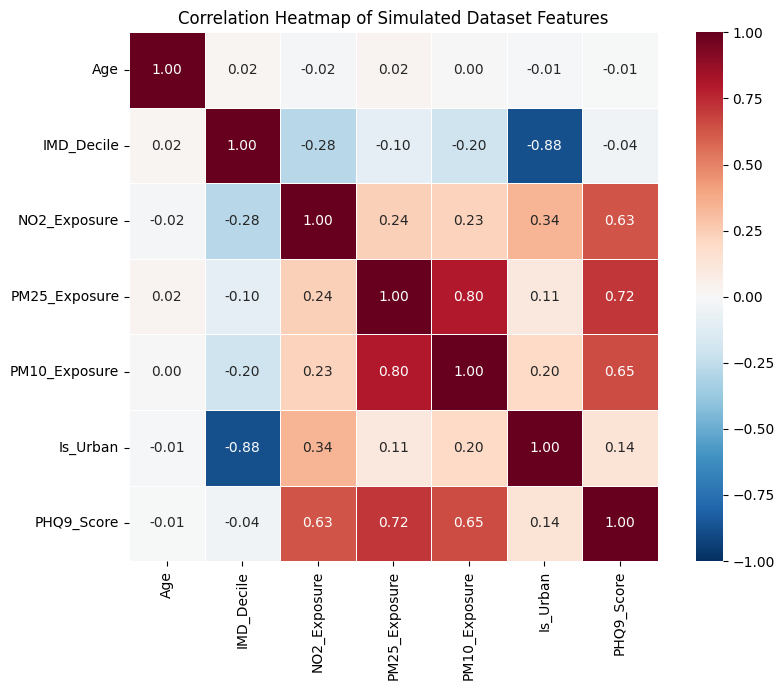

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Feature engineering for area-type numeric encoding used in correlation and ML
df['Is_Urban'] = np.where(df['Urban_Rural_Status'].str.startswith('Urban'), 1, 0)
if 'PHQ9_Score' not in df.columns:
    df['PHQ9_Score'] = df['PHQ9']

corr_features = ['Age', 'IMD_Decile', 'NO2_Exposure', 'PM25_Exposure', 'PM10_Exposure', 'Is_Urban', 'PHQ9_Score']
corr_matrix = df[corr_features].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Heatmap of Simulated Dataset Features')
plt.tight_layout()
plt.show()

## 4. Machine Learning Model
We use a Random Forest Regressor to predict PHQ-9 score from the simulated dataset.

The model input features are:
- `Age`
- `IMD_Decile`
- `NO2 Exposure`
- `PM25 Exposure`
- `PM10 Exposure`
- `Is Urban` (whether the participant is in an urban or rural area)

Random Forest can capture non-linear relationships and interactions without requiring strict linear assumptions, and remains stable when predictors are correlated (for example PM2.5 and PM10).

Training setup: the data are split into training (80%) and test (20%) sets.

Model performance is reported with test-set R-squared, RMSE, and MAE, followed by SHAP plots explaining which features drive predictions.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
import numpy as np

# Harmonize naming with the requested schema while keeping existing df as source.
df['Is_Urban'] = np.where(df['Urban_Rural_Status'].str.startswith('Urban'), 1, 0)
df['NO2'] = df['NO2_Exposure']
df['PM25'] = df['PM25_Exposure']
df['PM10'] = df['PM10_Exposure']

if 'PHQ9_Score' in df.columns:
    target_col = 'PHQ9_Score'
elif 'PHQ9' in df.columns:
    target_col = 'PHQ9'
    df['PHQ9_Score'] = df['PHQ9']
else:
    raise ValueError("Target column not found. Run the PHQ-9 simulation cell first.")

# Random Forest is used because it is robust to strong multicollinearity,
# including the high correlation (about 0.94) between PM2.5 and PM10.
feature_cols = ['Age', 'IMD_Decile', 'NO2', 'PM25', 'PM10', 'Is_Urban']
X = df[feature_cols]
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
pred = model.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print('Random Forest Regression Performance on Test Set:')
print(f'R-squared: {r2:.3f}')
print(f'RMSE: {rmse:.3f}')
print(f'MAE: {mae:.3f}')

Random Forest Regression Performance on Test Set:
R-squared: 0.734
RMSE: 2.055
MAE: 1.646


## 5. Model Visualisation (SHAP)
SHAP (SHapley Additive exPlanations) is used to interpret how each feature contributes to Random Forest predictions of PHQ-9.

In this notebook, we present:
- a SHAP summary (beeswarm) plot to show the direction and spread of feature effects across individuals
- a SHAP feature-importance bar plot to rank features by average absolute contribution

Together, these plots show both which variables matter most and whether higher or lower feature values tend to increase predicted mental health distress.

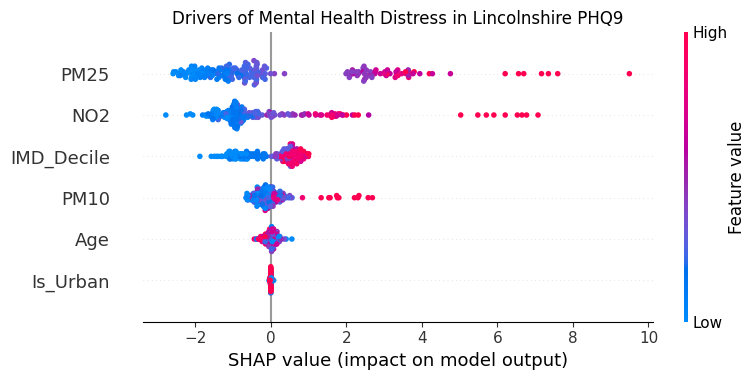

Each dot is one feature/person in the test set.
The position on the x-axis shows how much that feature influenced their predicted PHQ9 score,
with red dots indicating higher feature values and blue dots indicating lower feature values.


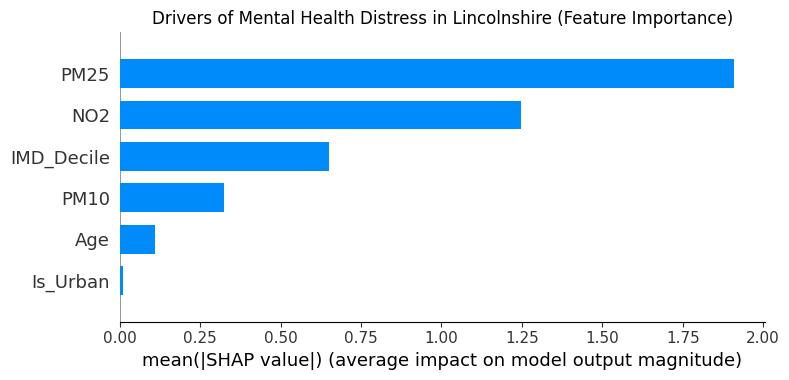

This bar chart ranks features by their average absolute SHAP value, showing which factors were most influential in the model's predictions of PHQ9 scores.


In [ ]:
import shap
import matplotlib.pyplot as plt

# TreeExplainer for Random Forest model
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# SHAP Summary Plot (dot/beeswarm)
shap.summary_plot(shap_values, X_test, show=False)
plt.title('Drivers of Mental Health Distress in Lincolnshire PHQ9')
plt.tight_layout()
plt.show()

print('Each dot is one feature/person in the test set.\nThe position on the x-axis shows how much that feature influenced their predicted PHQ9 score,\nwith red dots indicating higher feature values and blue dots indicating lower feature values.')

# SHAP Feature Importance Bar Chart
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.title('Drivers of Mental Health Distress in Lincolnshire (Feature Importance)')
plt.tight_layout()
plt.show()

print('This bar chart ranks features by their average absolute SHAP value, showing which factors were most influential in the model\'s predictions of PHQ9 scores.')

### Urban vs Rural comparison from test-set results
This section evaluates whether the trained Random Forest model preserves the urban-rural pattern in mental health scores on unseen test data.

The two plots show the results:
- a boxplot comparing score distributions by area type (Actual vs Predicted)
- a mean comparison plot showing average PHQ-9 by area type (Actual vs Predicted)

A summary table reports Urban and Rural mean PHQ-9 for both Actual and Predicted values.

If predicted urban and rural means are close to the actual urban and rural means, the model is capturing the group-level urban-rural signal rather than only fitting the overall average.

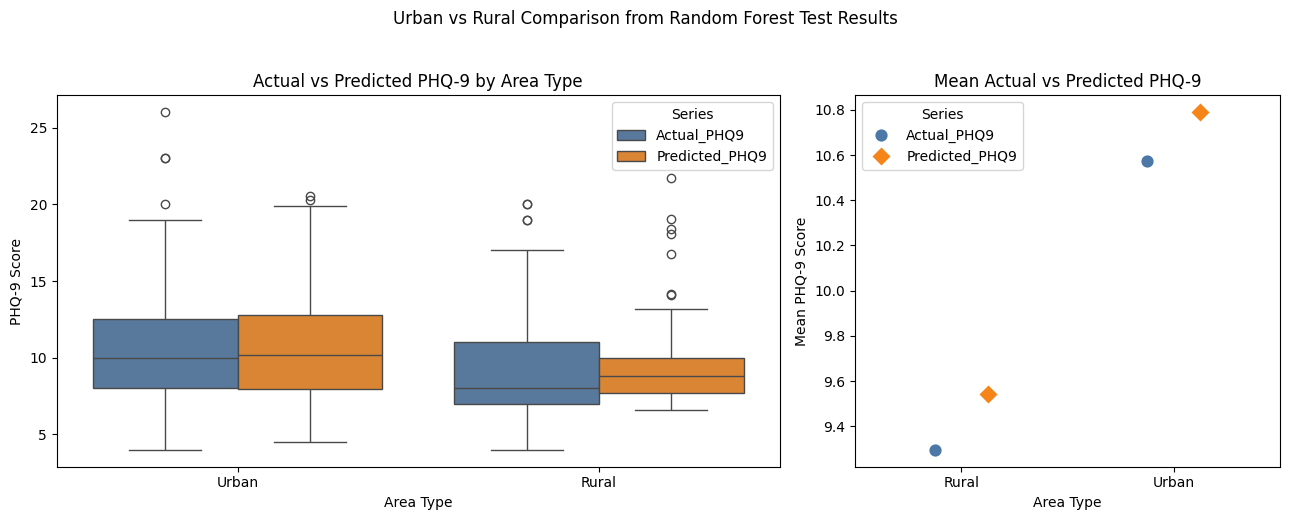

Urban vs Rural Random Forest results summary:


,Actual_Mean_PHQ9,Predicted_Mean_PHQ9
Area_Type,,
Rural,9.30,9.54
Urban,10.57,10.79


In [ ]:
# Urban vs Rural comparison using Random Forest test-set results
results_df = pd.DataFrame({
    'Area_Type': np.where(X_test['Is_Urban'] == 1, 'Urban', 'Rural'),
    'Actual_PHQ9': y_test.to_numpy(),
    'Predicted_PHQ9': pred
})

results_long = results_df.melt(
    id_vars='Area_Type',
    value_vars=['Actual_PHQ9', 'Predicted_PHQ9'],
    var_name='Series',
    value_name='PHQ9_Score'
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={'width_ratios': [1.7, 1]})

sns.boxplot(
    data=results_long,
    x='Area_Type',
    y='PHQ9_Score',
    hue='Series',
    palette={'Actual_PHQ9': '#4c78a8', 'Predicted_PHQ9': '#f58518'},
    ax=axes[0]
)
axes[0].set_title('Actual vs Predicted PHQ-9 by Area Type')
axes[0].set_xlabel('Area Type')
axes[0].set_ylabel('PHQ-9 Score')
axes[0].legend(title='Series')

mean_compare = (
    results_long
    .groupby(['Area_Type', 'Series'], as_index=False)['PHQ9_Score']
    .mean()
)

sns.pointplot(
    data=mean_compare,
    x='Area_Type',
    y='PHQ9_Score',
    hue='Series',
    palette={'Actual_PHQ9': '#4c78a8', 'Predicted_PHQ9': '#f58518'},
    dodge=0.25,
    linestyle='none',
    markers=['o', 'D'],
    ax=axes[1]
)
axes[1].set_title('Mean Actual vs Predicted PHQ-9')
axes[1].set_xlabel('Area Type')
axes[1].set_ylabel('Mean PHQ-9 Score')
axes[1].legend(title='Series')

plt.suptitle('Urban vs Rural Comparison from Random Forest Test Results', y=1.03)
plt.tight_layout()
plt.show()

model_group_summary = (
    results_df
    .groupby('Area_Type')
    .agg(
        Actual_Mean_PHQ9=('Actual_PHQ9', 'mean'),
        Predicted_Mean_PHQ9=('Predicted_PHQ9', 'mean')
    )
    .round(2)
)
print('Urban vs Rural Random Forest results summary:')
display(model_group_summary)

## Conclusion
Using real DEFRA AURN pollutant data linked to a simulated patient data in Lincolnshire, we observed a consistent urban-rural differnece in pollution exposure and mental health burden. Urban individuals showed higher predicted and observed PHQ-9 scores than rural individuals, and the Random Forest model reproduced this contrast on the test set.

Model performance was strong for this use case, indicating that the selected predictors captured a substantial share of variation in PHQ-9 in the simulated data. SHAP analyses showed that deprivation and pollution variables were among the main drivers of prediction.

Taken together, these results support the hypothesis that environmental exposure and social deprivation jointly align with higher mental health distress, with a stronger burden in urban settings.

### Limitations
This analysis remains a methodological demonstration with simulated data and outcomes.